In [1]:
#rmdopt echo = false
ensure_package <- function(pkg, repos = getOption("repos")) {
  # Quietly installs if not installed, and then loads the library
  if (!require(pkg, character.only = TRUE)) {
    install.packages(pkg, dependencies = TRUE, repos = repos)
  }
  library(pkg, character.only = TRUE)
}

# Geocomputation with R

In [11]:
ensure_package("sf")
ensure_package("terra")
ensure_package("tmap")
ensure_package("spData")
ensure_package("spDataLarge", repos = "https://nowosad.r-universe.dev")
ensure_package("geojsonio")
ensure_package("s2")
ensure_package("units")
ensure_package("tidyverse")

Loading required package: tmap



Breaking News: tmap 3.x is retiring. Please test v4, e.g. with
remotes::install_github('r-tmap/tmap')



The **sf** package provides classes for geographic data and a consistent CLI with low-level libraries for geocomputation:
- GDAL, for read/write and manipulation of a wide range of data formats
- PROJ, for coordinate system transformations
- GEOS, a planar geometry engine for calculating things like buffers and centroids in a CRS
- S2, a spherical geometry engine written by google

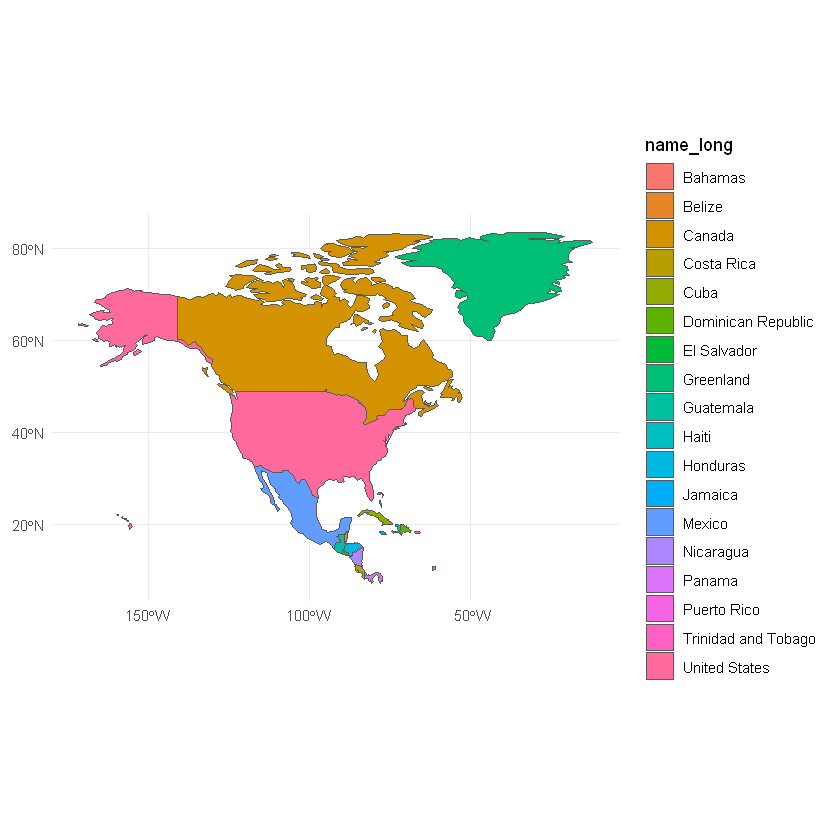

In [3]:
get_color <- function(n) {
  # Returns a vector of n colors
  scales::hue_pal()(n)
}

ggplot(world %>% filter(continent == "North America"), aes(fill = name_long)) +
  geom_sf() +
  theme_minimal()

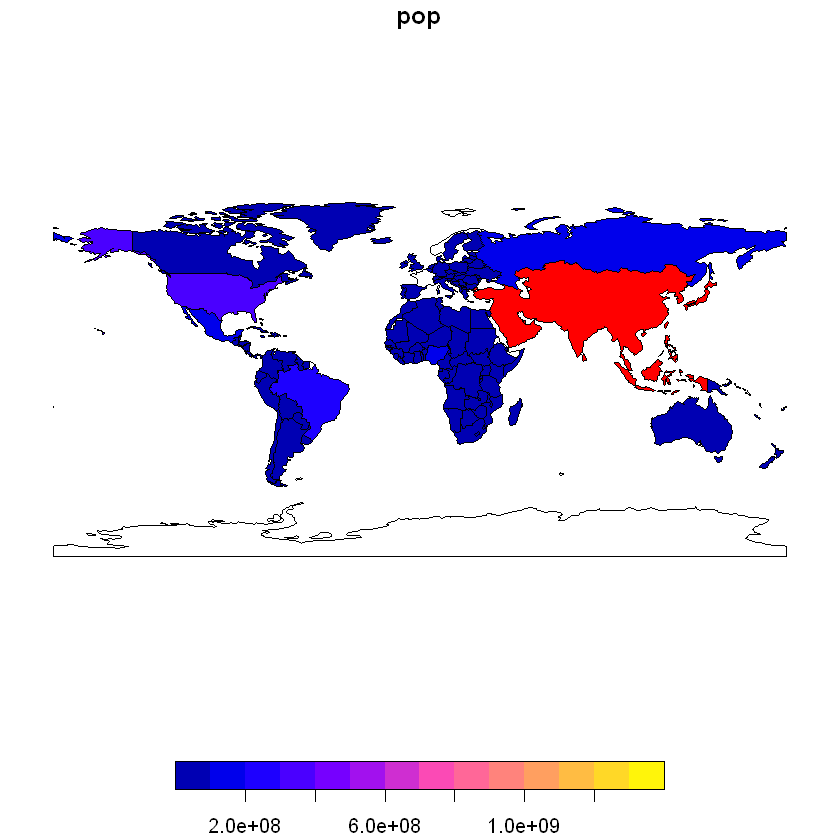

In [4]:
world_asia <- world[world$continent == "Asia", ]
asia <- st_union(world_asia)

plot(world["pop"], reset = FALSE)
plot(asia, add = TRUE, col = "red")

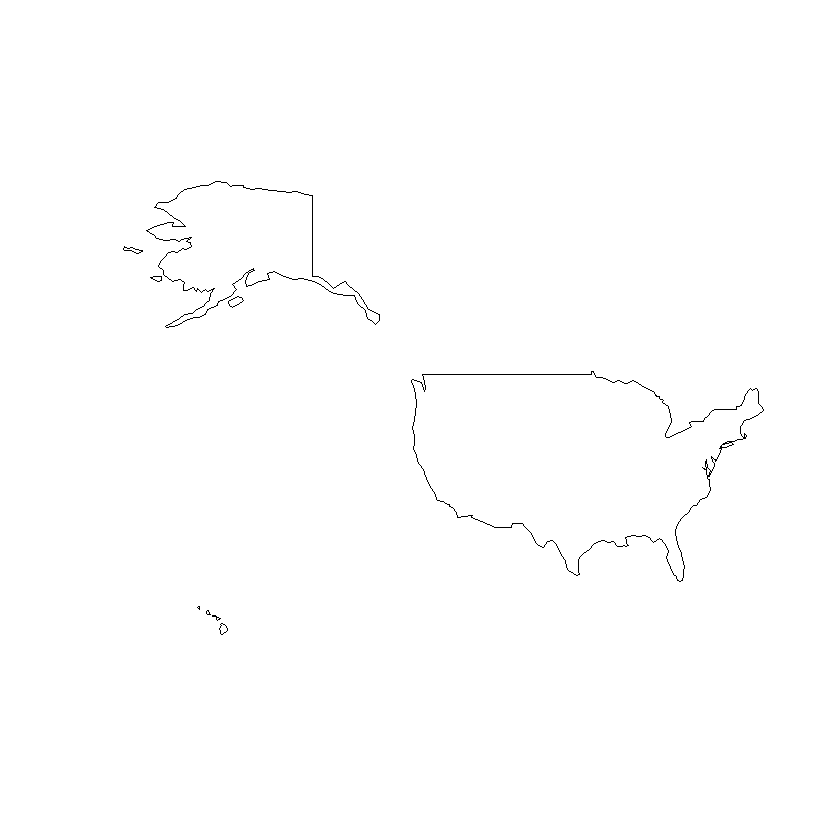

In [5]:
usa <- world[world$name_long == "United States", ]
plot(usa$geom)

In [6]:
lnd_point <- st_point(c(0.1, 51.5))                 # sfg object
lnd_geom <- st_sfc(lnd_point, crs = "EPSG:4326")    # sfc object
lnd_attrib <- data.frame(                           # data.frame object
  name <- "London",
  temperature <- 25,
  date <- as.Date("2023-06-21")
)
lnd_sf <- st_sf(lnd_attrib, geom = lnd_geom)    # sf object
class(lnd_sf)

[1] "sf"         "data.frame"

In [7]:
luxembourg <- world[world$name_long == "Luxembourg", ]
st_area(luxembourg)
units::set_units(st_area(luxembourg), km^2)

2408817306 [m^2]

2408.817 [km^2]

In [8]:
st_area(world)

glimpse(world)

Units: [m^2]
  [1] 1.935353e+10 9.367599e+11 9.648598e+10 9.984404e+12 9.494304e+12
  [6] 2.721834e+12 4.607394e+11 4.665215e+11 1.827305e+12 2.784660e+12
 [11] 8.143718e+11 2.333672e+12 4.864433e+11 5.934769e+11 1.857241e+12
 [16] 1.276148e+12 2.862841e+10 4.830628e+10 1.689506e+13 1.561590e+10
 [21] 1.630199e+10 3.953429e+11 2.189752e+12 1.156511e+10 1.477639e+10
 [26] 1.218030e+12 2.753884e+10 1.973908e+12 1.769515e+11 8.540954e+12
 [31] 1.088908e+12 1.315037e+12 1.156933e+12 7.558109e+10 5.405211e+10
 [36] 1.300354e+11 1.142005e+11 2.097135e+10 1.098424e+11 2.211851e+10
 [41] 9.123672e+11 2.107215e+11 1.449060e+11 6.437919e+11 2.518690e+11
 [46] 9.253941e+09 1.250032e+10 1.151721e+11 3.774849e+11 5.934392e+11
 [51] 8.270085e+11 1.951022e+11 1.239602e+12 1.057125e+12 1.174789e+11
 [56] 1.186140e+12 9.087836e+11 4.623214e+11 6.122266e+10 2.445015e+11
 [61] 3.312277e+11 2.405339e+11 3.633314e+10 9.863092e+10 7.629890e+10
 [66] 2.726460e+11 6.245380e+11 3.411986e+11 2.706834e+11 2.7242

Rows: 177
Columns: 11
$ iso_a2    <chr> "FJ", "TZ", "EH", "CA", "US", "KZ", "UZ", "PG", "ID", "AR", …
$ name_long <chr> "Fiji", "Tanzania", "Western Sahara", "Canada", "United Stat…
$ continent <chr> "Oceania", "Africa", "Africa", "North America", "North Ameri…
$ region_un <chr> "Oceania", "Africa", "Africa", "Americas", "Americas", "Asia…
$ subregion <chr> "Melanesia", "Eastern Africa", "Northern Africa", "Northern …
$ type      <chr> "Sovereign country", "Sovereign country", "Indeterminate", "…
$ area_km2  <dbl> 19289.97, 932745.79, 96270.60, 10036042.98, 9510743.74, 2729…
$ pop       <dbl> 885806, 52234869, NA, 35535348, 318622525, 17288285, 3075770…
$ lifeExp   <dbl> 69.96000, 64.16300, NA, 81.95305, 78.84146, 71.62000, 71.039…
$ gdpPercap <dbl> 8222.2538, 2402.0994, NA, 43079.1425, 51921.9846, 23587.3375…
$ geom      <MULTIPOLYGON [°]> MULTIPOLYGON (((-180 -16.55..., MULTIPOLYGON ((…


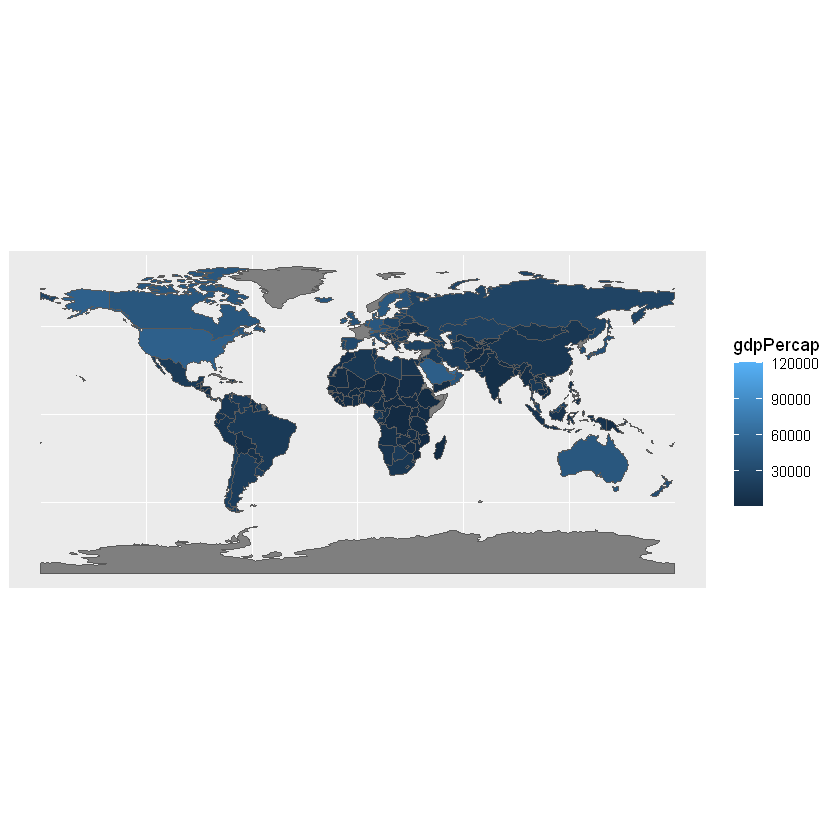

In [9]:
ggplot(world) +
  geom_sf(aes(fill = gdpPercap))